# Dataset extraction

In [ ]:
# extract the dataset
import tarfile

# Name of the uploaded file
tar_path = "/TCGA-PANCAN-HiSeq-801x20531.tar.gz"

# Extract everything into the current folder
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall()

print("Dataset extracted successfully!")

/tmp/ipykernel_1408/581004173.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset extracted successfully!


In [ ]:
#  See what was extracted
import os

# List all files in the current directory
print(os.listdir())

['.config', 'TCGA-PANCAN-HiSeq-801x20531', 'sample_data']


In [ ]:
#  See what's inside the dataset folder
import os

folder = "TCGA-PANCAN-HiSeq-801x20531"

print(os.listdir(folder))

['labels.csv', 'data.csv']


In [ ]:
#import libraries
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load gene expression data
data = pd.read_csv("TCGA-PANCAN-HiSeq-801x20531/data.csv")

# Load cancer labels
labels = pd.read_csv("TCGA-PANCAN-HiSeq-801x20531/labels.csv")

print("Data loaded successfully!")

Data loaded successfully!


In [ ]:
# Display first 5 rows of the gene expression data
data.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [ ]:
# Display first 5 rows of the labels
labels.head()

,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


# Dataset Exploration

In [ ]:
# Shape of the datasets
print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

print("\n" + "="*50)

# Information about the data
print("Data Information:")
data.info()

print("\n" + "="*50)

# Check for missing values
print("Missing values in data:")
print(data.isnull().sum().sum())

print("\nMissing values in labels:")
print(labels.isnull().sum().sum())

print("\n" + "="*50)

# Count of each cancer type
print("Cancer Class Distribution:")
print(labels["Class"].value_counts())

Data shape: (801, 20532)
Labels shape: (801, 2)

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20532 entries, Unnamed: 0 to gene_20530
dtypes: float64(20531), object(1)
memory usage: 125.5+ MB

Missing values in data:
0

Missing values in labels:
0

Cancer Class Distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


# Dataset Visualise

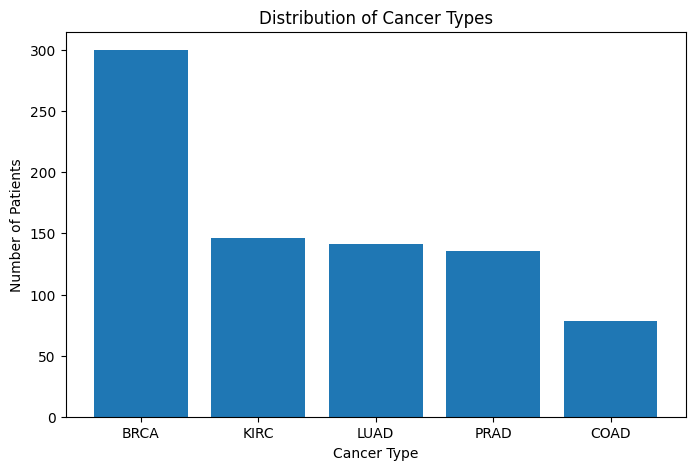

In [ ]:
import matplotlib.pyplot as plt
class_counts = labels["Class"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(class_counts.index, class_counts.values)

plt.title("Distribution of Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Number of Patients")

plt.show()

# Data Preprocessing

In [ ]:
# Remove the patient ID column
X = data.drop(columns=["Unnamed: 0"])

# Display the first few rows
X.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [ ]:
# Store the cancer labels
y = labels["Class"]

# Display first few labels
y.head()

,Class
0,PRAD
1,LUAD
2,PRAD
3,PRAD
4,BRCA


In [ ]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (801, 20531)
Target shape: (801,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create the encoder
label_encoder = LabelEncoder()

# Convert cancer names to numbers
y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:")
print(y_encoded[:10])

Encoded labels:
[4 3 4 4 0 4 2 4 0 4]


In [ ]:
#see the mapping

mapping = dict(zip(label_encoder.classes_,
                   label_encoder.transform(label_encoder.classes_)))

print(mapping)

{'BRCA': np.int64(0), 'COAD': np.int64(1), 'KIRC': np.int64(2), 'LUAD': np.int64(3), 'PRAD': np.int64(4)}


#Splitting training and test data

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Display the shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (640, 20531)
Testing Features  : (161, 20531)
Training Labels   : (640,)
Testing Labels    : (161,)


#Baseline Model - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
# Predict the test set
y_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


# Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)


print(f"Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 99.38%

Classification Report
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161


Confusion Matrix
[[60  0  0  0  0]
 [ 0 16  0  0  0]
 [ 0  0 30  0  0]
 [ 1  0  0 27  0]
 [ 0  0  0  0 27]]


In [ ]:
import joblib
from google.colab import files

# Save the trained model
joblib.dump(rf_model, "random_forest.pkl")

# Download to your computer
files.download("random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save the label encoder

import joblib
from google.colab import files

joblib.dump(label_encoder, "label_encoder.pkl")

files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save x_train and x_test
from google.colab import files

X_train.to_csv("X_train.csv", index=False)

files.download("X_train.csv")

from google.colab import files

X_test.to_csv("X_test.csv", index=False)

files.download("X_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# save y_train and y_test
import pandas as pd
from google.colab import files

pd.DataFrame(y_train, columns=["Cancer"]).to_csv(
    "y_train.csv",
    index=False
)

files.download("y_train.csv")

pd.DataFrame(y_test, columns=["Cancer"]).to_csv(
    "y_test.csv",
    index=False
)

files.download("y_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save predictions
import pandas as pd
from google.colab import files

predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

predictions.to_csv("predictions.csv", index=False)

files.download("predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Logistic Regression

In [15]:
import pandas as pd

try:
    X_train = pd.read_csv("X_train.csv")
    X_test = pd.read_csv("X_test.csv")
    y_train = pd.read_csv("y_train.csv").squeeze()
    y_test = pd.read_csv("y_test.csv").squeeze()

    print("Datasets loaded successfully!")

except FileNotFoundError:
    print("Error: One or more CSV files were not found.")

except Exception as e:
    print(f"Error: {e}")

Datasets loaded successfully!


In [16]:
# ============================================================
# Verify the Loaded Data
# ============================================================

try:
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)

    total_samples = len(X_train) + len(X_test)
    print(f"\nTotal samples: {total_samples}")

except Exception as e:
    print(f"Error while verifying data:\n{e}")

X_train: (640, 20531)
X_test : (161, 20531)
y_train: (640,)
y_test : (161,)

Total samples: 801


In [17]:
# ============================================================
# Step 8: Standardize Features for Logistic Regression
# ============================================================

from sklearn.preprocessing import StandardScaler

try:
    # Create a StandardScaler instance.
    # The scaler learns the mean and standard deviation
    # from the training data only.
    scaler = StandardScaler()

    # Fit the scaler on the training data and transform it.
    X_train_scaled = scaler.fit_transform(X_train)

    # Apply the same scaling parameters to the test data.
    X_test_scaled = scaler.transform(X_test)

    # Display confirmation and dataset dimensions.
    print("Feature scaling completed successfully.")
    print(f"Training data shape: {X_train_scaled.shape}")
    print(f"Testing data shape : {X_test_scaled.shape}")

except NameError as e:
    print(f"Variable not found: {e}")
    print("Ensure that X_train and X_test have been loaded before scaling.")

except Exception as e:
    print(f"An unexpected error occurred during feature scaling: {e}")

Feature scaling completed successfully.
Training data shape: (640, 20531)
Testing data shape : (161, 20531)


In [34]:
# ============================================================
# Step 9: Train the Logistic Regression Model
# ============================================================

# Import the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

try:
    # Create the Logistic Regression model.
    #
    # max_iter:
    # Logistic Regression may require more than the default
    # number of iterations to converge on high-dimensional
    # datasets such as gene expression data.
    #
    # random_state:
    # Ensures reproducibility of results.
    logistic_model = LogisticRegression(
        C=0.1,
        max_iter=200,
        random_state=42
    )

    print("Training Logistic Regression model...")

    # Train the model using the standardized training data
    logistic_model.fit(X_train_scaled, y_train)

    print("Model training completed successfully.")

except Exception as e:
    print(f"An error occurred while training the model:\n{e}")

Training Logistic Regression model...
Model training completed successfully.


In [35]:
# ============================================================
# Step 10: Make Predictions
# ============================================================

try:
    # Predict the cancer type for each sample in the test set
    y_pred_lr = logistic_model.predict(X_test_scaled)

    print("Predictions generated successfully.")
    print(f"Number of predictions: {len(y_pred_lr)}")

except Exception as e:
    print(f"An error occurred during prediction:\n{e}")

Predictions generated successfully.
Number of predictions: 161


In [36]:
# ============================================================
# Load the Saved Label Encoder (lost due to Colab runtime)
# ============================================================

import joblib

try:
    # Load the previously saved LabelEncoder object
    label_encoder = joblib.load("label_encoder.pkl")

    print("Label encoder loaded successfully.")
    print(f"Number of classes: {len(label_encoder.classes_)}")

except FileNotFoundError:
    print("Error: 'label_encoder.pkl' was not found.")
    print("Ensure the file is in the current working directory.")

except Exception as e:
    print(f"An unexpected error occurred:\n{e}")

Label encoder loaded successfully.
Number of classes: 5


In [37]:
# ============================================================
# Step 11: Evaluate the Logistic Regression Model
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

try:
    # Calculate overall accuracy
    accuracy = accuracy_score(y_test, y_pred_lr)

    print("=" * 60)
    print("Logistic Regression Evaluation")
    print("=" * 60)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Accuracy : {accuracy * 100:.2f}%")

    print("\nClassification Report")
    print("-" * 60)

    print(
        classification_report(
            y_test,
            y_pred_lr,
            target_names=label_encoder.classes_
        )
    )

    print("\nConfusion Matrix")
    print("-" * 60)

    print(confusion_matrix(y_test, y_pred_lr))

except Exception as e:
    print(f"An error occurred during evaluation:\n{e}")

Logistic Regression Evaluation

Accuracy : 0.9938
Accuracy : 99.38%

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161


Confusion Matrix
------------------------------------------------------------
[[60  0  0  0  0]
 [ 0 16  0  0  0]
 [ 0  0 30  0  0]
 [ 1  0  0 27  0]
 [ 0  0  0  0 27]]


In [41]:
# ============================================================
# Save the Trained Logistic Regression Model
# ============================================================

import joblib
from google.colab import files

try:
    joblib.dump(logistic_model, "logistic_regression.pkl")
    print("Logistic Regression model saved successfully.")

except Exception as e:
    print(f"Error saving Logistic Regression model:\n{e}")

# Download to your computer
files.download("logistic_regression.pkl")

Logistic Regression model saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# ============================================================
# Save the StandardScaler
# ============================================================

import joblib
from google.colab import files

try:
    joblib.dump(scaler, "standard_scaler.pkl")
    print("StandardScaler saved successfully.")

except Exception as e:
    print(f"Error saving StandardScaler:\n{e}")


# Download to your computer
files.download("standard_scaler.pkl")


StandardScaler saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
# ============================================================
# Save Logistic Regression Predictions
# ============================================================

import pandas as pd
from google.colab import files

try:
    # Create a DataFrame containing actual and predicted labels
    predictions_lr = pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred_lr
    })

    # Save the predictions as a CSV file
    predictions_lr.to_csv(
        "logistic_regression_predictions.csv",
        index=False
    )

    print("Predictions saved successfully.")

except Exception as e:
    print(f"Error saving predictions:\n{e}")


# Download the file to your computer
files.download("logistic_regression_predictions.csv")

Predictions saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# ============================================================
# Save Logistic Regression Metrics
# ============================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from google.colab import files

try:
    # Create a DataFrame containing the evaluation metrics
    metrics = pd.DataFrame({
        "Model": ["Logistic Regression"],
        "Accuracy": [accuracy_score(y_test, y_pred_lr)],
        "Precision (Weighted)": [
            precision_score(y_test, y_pred_lr, average="weighted")
        ],
        "Recall (Weighted)": [
            recall_score(y_test, y_pred_lr, average="weighted")
        ],
        "F1 Score (Weighted)": [
            f1_score(y_test, y_pred_lr, average="weighted")
        ]
    })

    # Save the metrics as a CSV file
    metrics.to_csv(
        "logistic_regression_metrics.csv",
        index=False
    )

    print("Metrics saved successfully.")

except Exception as e:
    print(f"Error saving metrics:\n{e}")


# Download the file to your computer
files.download("logistic_regression_metrics.csv")

Metrics saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>